# Transformacion de datos


In [1]:
# transformacion de datos
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
# cargar datos
data = pd.read_csv('data.csv')

In [2]:
# separar características y etiquetas
X = data.drop('target', axis=1) # características
y = data['target'] # etiquetas

In [25]:
print(X.head())
print("--       ----                --  ")  
print(y.head()) 


   edad  ingreso_mensual  transacciones  genero       comuna membresia
0  25.0         820000.0            4.0   Mujer     Santiago    Basica
1  34.0        1450000.0            9.0  Hombre  Providencia   Premium
2  29.0        1100000.0            6.0   Mujer        Maipu    Basica
3  45.0        1950000.0           14.0  Hombre   Las Condes   Premium
4  38.0        1620000.0           11.0   Mujer        Nunoa   Premium
--       ----                --  
0    0
1    1
2    0
3    1
4    1
Name: target, dtype: int64


In [3]:
# identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
print("Columnas numéricas:", numeric_features)
print("-----------------------------------------------------")
categorical_features = X.select_dtypes(include=['object']).columns
print("Columnas categóricas:", categorical_features)
print("-----------------------------------------------------")

# category2=X.select_dtypes(include=["object", "string"])
# print(category2.head())

Columnas numéricas: Index(['edad', 'ingreso_mensual', 'transacciones'], dtype='str')
-----------------------------------------------------
Columnas categóricas: Index(['genero', 'comuna', 'membresia'], dtype='str')
-----------------------------------------------------


C:\Users\ocog1\AppData\Local\Temp\ipykernel_16700\3668097354.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


In [12]:
X.info()   
X.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   edad             39 non-null     float64
 1   ingreso_mensual  39 non-null     float64
 2   transacciones    39 non-null     float64
 3   genero           39 non-null     str    
 4   comuna           39 non-null     str    
 5   membresia        40 non-null     str    
dtypes: float64(3), str(3)
memory usage: 2.0 KB


,edad,ingreso_mensual,transacciones
count,39.000000,3.900000e+01,39.000000
mean,37.000000,1.541538e+06,9.769231
std,8.175702,4.416210e+05,3.923355
min,24.000000,7.800000e+05,3.000000
25%,30.000000,1.245000e+06,7.000000
50%,36.000000,1.530000e+06,10.000000
75%,43.500000,1.870000e+06,12.500000
max,53.000000,2.380000e+06,18.000000


In [4]:
# crear transformadores para datos numéricos y categóricos
numeric_transformer = Pipeline(steps=[  
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
]) #explicacion: se crea un pipeline para los datos numéricos que primero imputa los 
# valores faltantes con la media y luego escala los datos utilizando StandardScaler. 
# Esto asegura que los datos numéricos estén limpios y en una escala adecuada para el modelo de machine learning.

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])  #explicacion: se crea un pipeline para los datos categóricos que primero 
# imputa los valores faltantes con la moda (valor más frecuente) y luego aplica OneHotEncoder 
# para convertir las variables categóricas en variables dummy (binarias). El parámetro handle_unknown='ignore' 
# asegura que si hay categorías en el conjunto de prueba que no estaban presentes en el conjunto de entrenamiento, 
# no se generará un error.

# que es un pipeline: es una secuencia de pasos de transformación de datos que se aplican de manera ordenada. 
# Cada paso del pipeline puede ser un transformador (como imputer o scaler) o un modelo de machine learning. 
# El pipeline permite encadenar estas transformaciones y modelos de manera eficiente, asegurando que se apliquen 
# en el orden correcto durante el entrenamiento y la predicción.

print(numeric_transformer)
print("-----------------------------------------------------")
print(categorical_transformer)



Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])
-----------------------------------------------------
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])


In [5]:
# combinar transformadores en un preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
) #explicacion: se combina el transformador de datos numéricos y categóricos en un ColumnTransformer. 
# Esto permite aplicar las transformaciones específicas a cada tipo de dato en el conjunto de características (X). 
# El preprocesador se encargará de aplicar el pipeline de datos numéricos a las columnas numéricas y el pipeline 
#   de datos categóricos a las columnas categóricas, asegurando que cada tipo de dato se procese adecuadamente
#  antes de ser utilizado en el modelo de machine learning.
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['edad', 'ingreso_mensual', 'transacciones'], dtype='str')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['genero', 'comuna', 'membresia'], dtype='str'))])


In [6]:
# crear pipeline completo con preprocesador y modelo
pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
]) #explicacion: se crea un pipeline completo que incluye el preprocesador 
# (que combina las transformaciones para datos numéricos y categóricos)
print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['edad', 'ingreso_mensual', 'transacciones'], dtype='str')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                  

Accuracy: 1.000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

Archivo generado: dataset_mejorado.csv
Dimensiones del dataset mejorado: (40, 19)
Resumen estadistico del dataset mejorado:
       num__edad  num__ingreso_mensual  num__transacciones  \
count  40.000000             40.000000           40.000000   
mean   -0.010822             -0.027210           -0.055079   
std     0.955507              0.961326            0.948071   
min    -1.550290             -1.707287           -1.713572   
25%    -0.839894             -0.665308           -0.734388   
50%    -0.070300             -0.026676            0.000000   
75%     0.728895              0.685405            0.550791   
max     1.8832

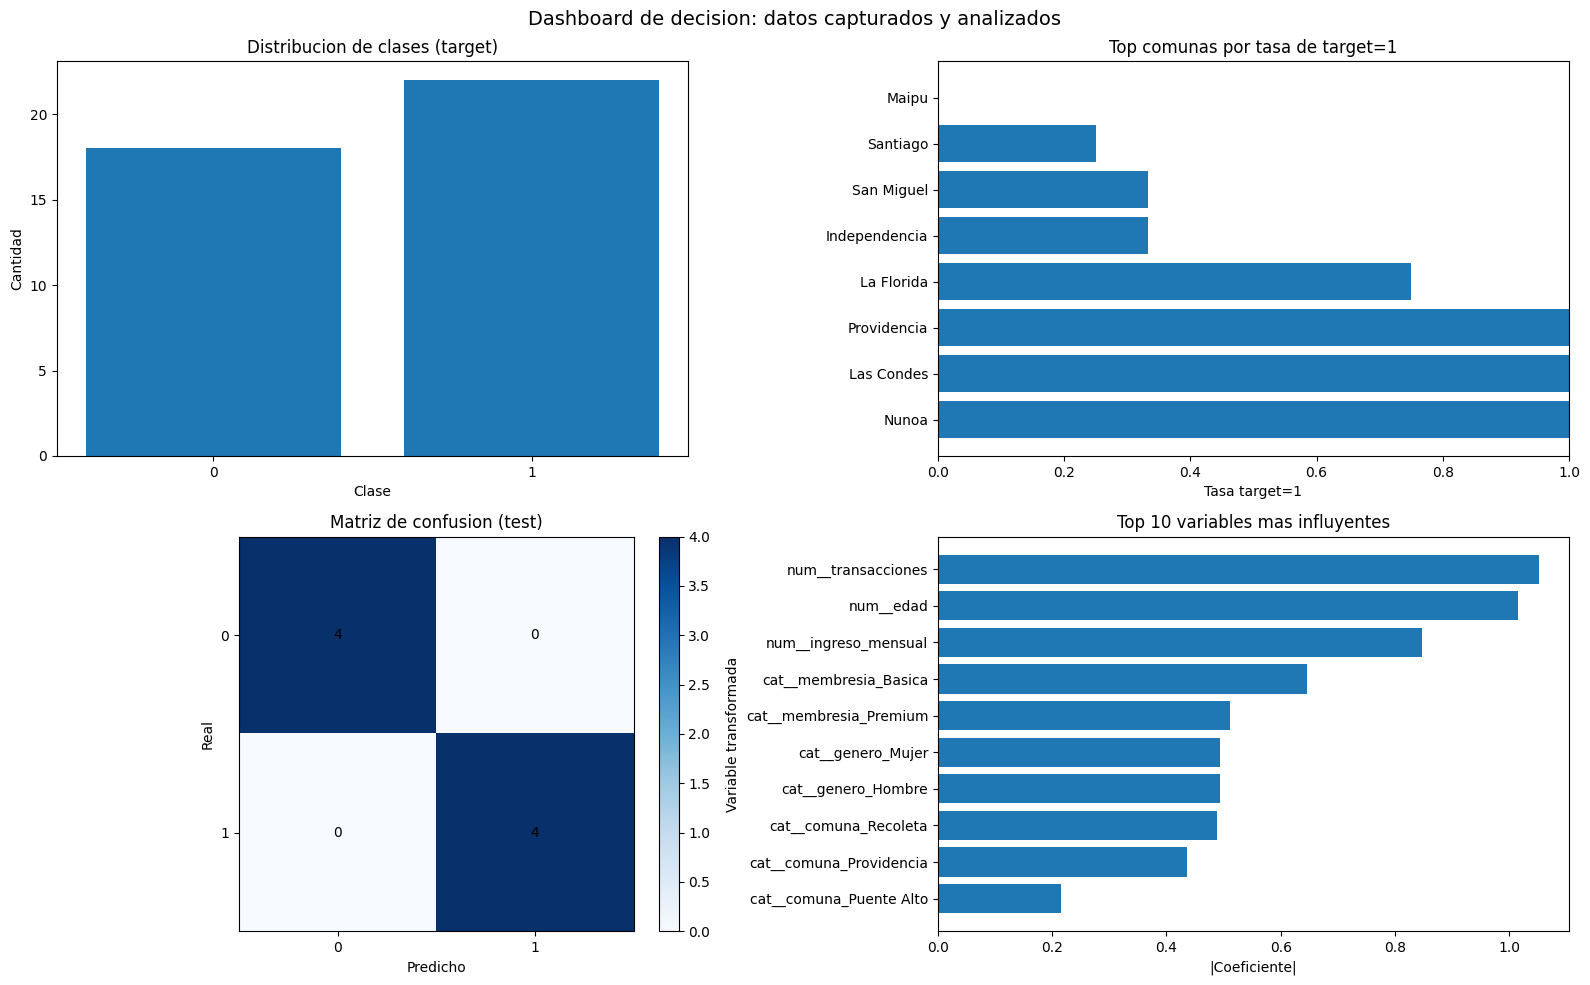

In [7]:
# dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# entrenar modelo
pipeline.fit(X_train, y_train)

# hacer predicciones
y_pred = pipeline.predict(X_test)

# evaluar modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.3f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

# ------------------------------
# exportar dataset mejorado
# ------------------------------
# Se transforma todo X con el preprocesador ya entrenado (sin target)
X_trans_full = pipeline.named_steps['preprocessor'].transform(X)
if hasattr(X_trans_full, 'toarray'):
    X_trans_full = X_trans_full.toarray()

# Nombres finales de columnas transformadas
columnas_transformadas = pipeline.named_steps['preprocessor'].get_feature_names_out()

# DataFrame final mejorado + target
dataset_mejorado = pd.DataFrame(X_trans_full, columns=columnas_transformadas)
dataset_mejorado['target'] = y.values

# Guardar archivo CSV
dataset_mejorado.to_csv('dataset_mejorado.csv', index=False)
print('Archivo generado: dataset_mejorado.csv')
print('Dimensiones del dataset mejorado:', dataset_mejorado.shape)

# Mostrar resumen estadistico del nuevo dataframe
print('Resumen estadistico del dataset mejorado:')
print(dataset_mejorado.describe(include='all'))

# ------------------------------
# dashboard para toma de decisiones
# ------------------------------
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# KPI basicos
total_registros = len(data)
tasa_objetivo_1 = y.mean()
print(f'Total de registros: {total_registros}')
print(f'Tasa de target=1: {tasa_objetivo_1:.2%}')

# 1) Distribucion de clases (target)
conteo_target = y.value_counts().sort_index()

# 2) Tasa de target=1 por comuna (si existe la columna comuna)
if 'comuna' in X.columns:
    tasa_por_comuna = data.groupby('comuna')['target'].mean().sort_values(ascending=False)
    top_comunas = tasa_por_comuna.head(8)
else:
    top_comunas = pd.Series(dtype=float)

# 3) Matriz de confusion
cm = confusion_matrix(y_test, y_pred)

# 4) Variables mas influyentes segun coeficientes del modelo
coef = pipeline.named_steps['classifier'].coef_[0]
importancia = pd.DataFrame({
    'feature': columnas_transformadas,
    'coef_abs': np.abs(coef),
    'coef': coef
}).sort_values('coef_abs', ascending=False)
top_importancia = importancia.head(10).iloc[::-1]

# Construccion del dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel A: Distribucion de clases
axes[0, 0].bar(conteo_target.index.astype(str), conteo_target.values)
axes[0, 0].set_title('Distribucion de clases (target)')
axes[0, 0].set_xlabel('Clase')
axes[0, 0].set_ylabel('Cantidad')

# Panel B: Tasa de target=1 por comuna
if len(top_comunas) > 0:
    axes[0, 1].barh(top_comunas.index, top_comunas.values)
    axes[0, 1].set_title('Top comunas por tasa de target=1')
    axes[0, 1].set_xlabel('Tasa target=1')
    axes[0, 1].set_xlim(0, 1)
else:
    axes[0, 1].text(0.5, 0.5, 'No existe columna comuna', ha='center', va='center')
    axes[0, 1].set_title('Top comunas por tasa de target=1')
    axes[0, 1].set_axis_off()

# Panel C: Matriz de confusion
im = axes[1, 0].imshow(cm, cmap='Blues')
axes[1, 0].set_title('Matriz de confusion (test)')
axes[1, 0].set_xlabel('Predicho')
axes[1, 0].set_ylabel('Real')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1, 0].text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Panel D: Top variables influyentes
axes[1, 1].barh(top_importancia['feature'], top_importancia['coef_abs'])
axes[1, 1].set_title('Top 10 variables mas influyentes')
axes[1, 1].set_xlabel('|Coeficiente|')
axes[1, 1].set_ylabel('Variable transformada')

plt.suptitle('Dashboard de decision: datos capturados y analizados', fontsize=14)
plt.tight_layout()
plt.show()

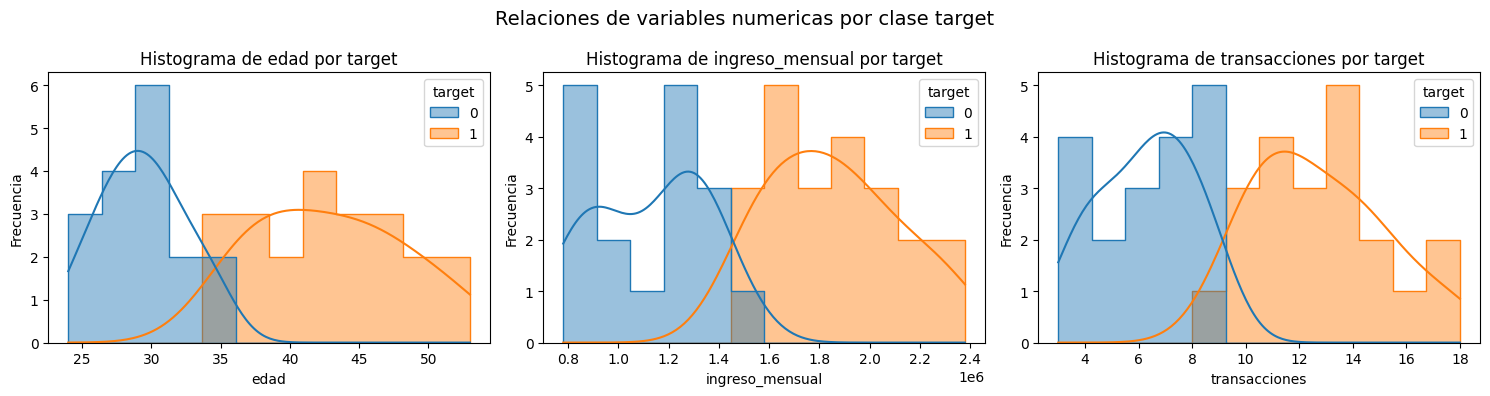

In [28]:
# ------------------------------
# histograma de relaciones entre variables
# ------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# columnas numericas disponibles en los datos originales
cols_num = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

if len(cols_num) == 0:
    print('No hay variables numericas para graficar.')
else:
    n_cols = min(3, len(cols_num))
    n_rows = (len(cols_num) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols_num):
        sns.histplot(
            data=data,
            x=col,
            hue='target',
            kde=True,
            bins=12,
            stat='count',
            alpha=0.45,
            element='step',
            ax=axes[i]
        )
        axes[i].set_title(f'Histograma de {col} por target')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')

    # ocultar ejes sobrantes si los hay
    for j in range(len(cols_num), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Relaciones de variables numericas por clase target', fontsize=14)
    plt.tight_layout()
    plt.show()

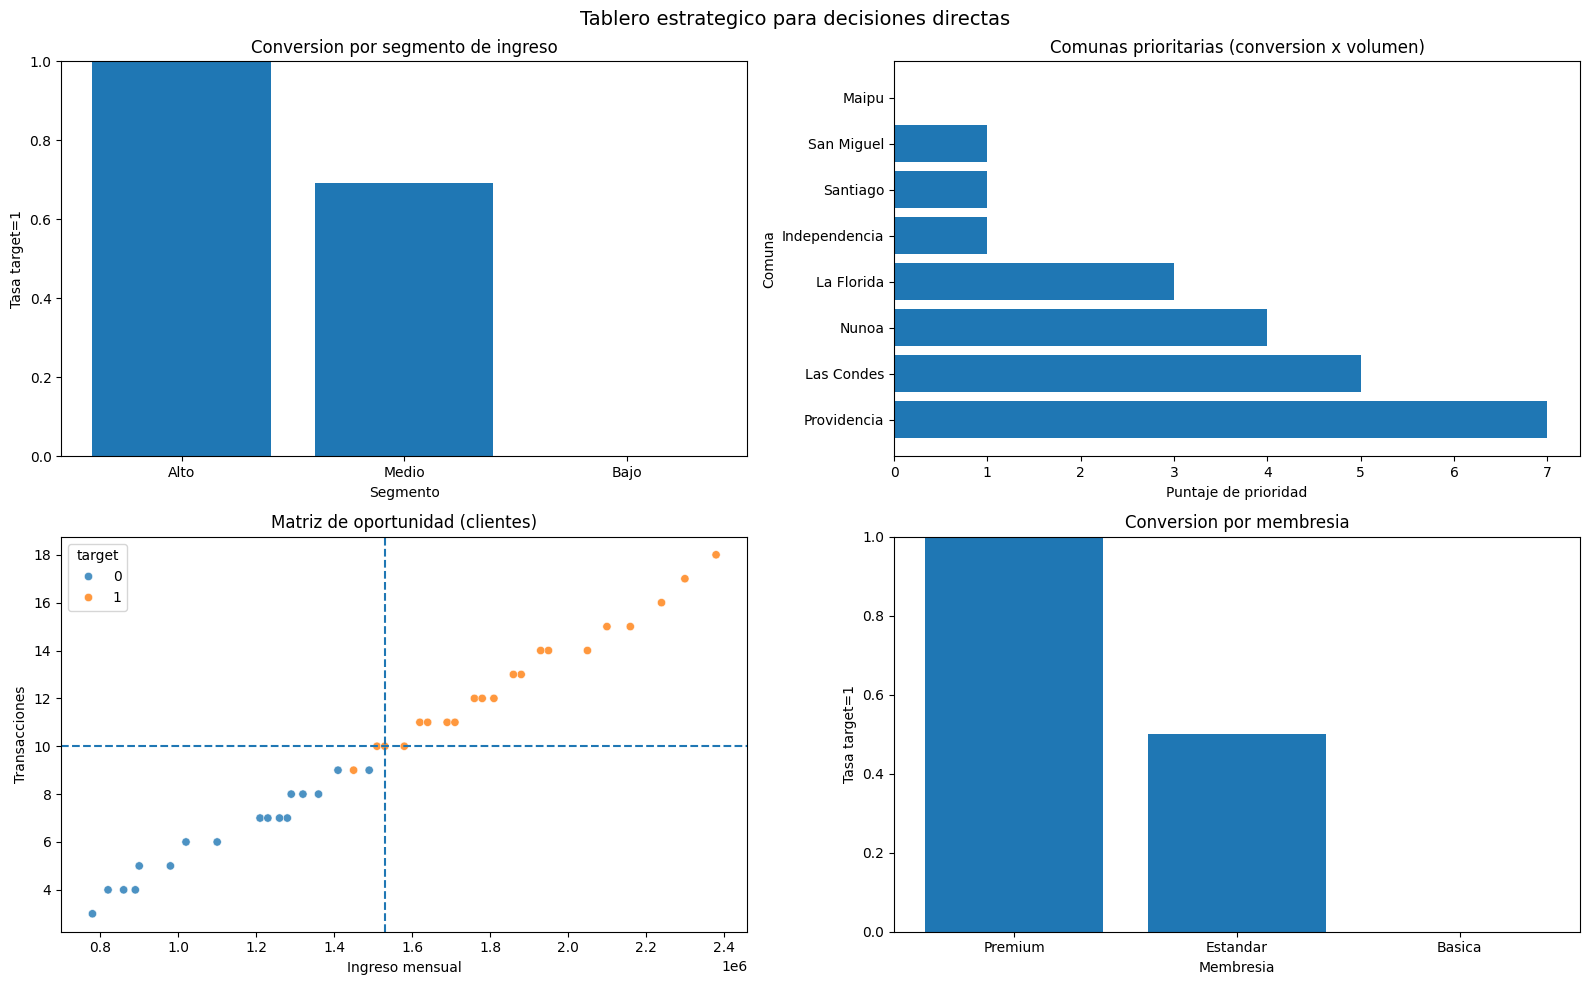


RECOMENDACIONES DIRECTAS:
1) Priorizar campanas en segmento de ingreso: Alto
2) Priorizar gestion comercial en comuna: Providencia
3) Atacar cuadrante de alto ingreso y altas transacciones para conversion rapida.


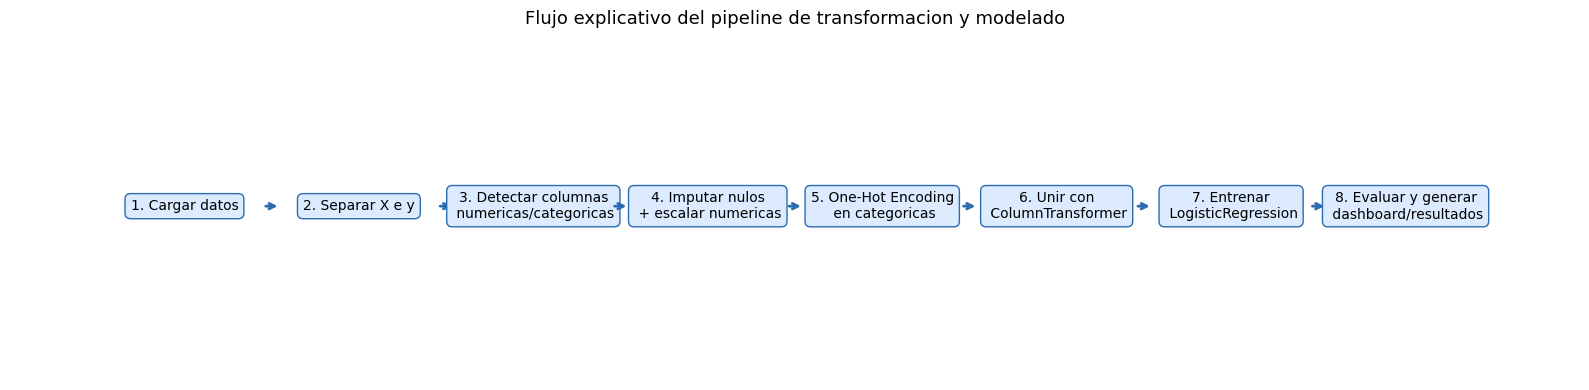

Se guardo la imagen del flujo en: flujo_pipeline.png
Se genero el PPTX: flujo_pipeline_explicativo.pptx


In [8]:
# ------------------------------
# graficos estrategicos para decisiones directas
# ------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path

# trabajar con una copia para analisis estrategico
df = data.copy()

# validar columnas clave
required_cols = {'target', 'ingreso_mensual', 'transacciones', 'comuna'}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    print(f'Faltan columnas para el tablero estrategico: {missing_cols}')
else:
    # 1) Segmentacion por ingreso (bajo/medio/alto)
    df['segmento_ingreso'] = pd.qcut(df['ingreso_mensual'], q=3, labels=['Bajo', 'Medio', 'Alto'])
    conv_segmento = df.groupby('segmento_ingreso', observed=True)['target'].mean().sort_values(ascending=False)

    # 2) Comunas prioritarias (conversion x volumen)
    comunas = df.groupby('comuna').agg(
        conversion=('target', 'mean'),
        volumen=('target', 'size')
    )
    comunas['puntaje_prioridad'] = comunas['conversion'] * comunas['volumen']
    comunas_top = comunas.sort_values('puntaje_prioridad', ascending=False).head(8)

    # 3) Matriz de oportunidad por cliente (ingreso x transacciones)
    ingreso_mediana = df['ingreso_mensual'].median()
    trans_mediana = df['transacciones'].median()

    # 4) Impacto de membresia en conversion
    if 'membresia' in df.columns:
        conv_membresia = df.groupby('membresia')['target'].mean().sort_values(ascending=False)
    else:
        conv_membresia = pd.Series(dtype=float)

    # dashboard estrategico
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Panel A: conversion por segmento de ingreso
    axes[0, 0].bar(conv_segmento.index.astype(str), conv_segmento.values)
    axes[0, 0].set_title('Conversion por segmento de ingreso')
    axes[0, 0].set_xlabel('Segmento')
    axes[0, 0].set_ylabel('Tasa target=1')
    axes[0, 0].set_ylim(0, 1)

    # Panel B: comunas prioritarias
    axes[0, 1].barh(comunas_top.index, comunas_top['puntaje_prioridad'])
    axes[0, 1].set_title('Comunas prioritarias (conversion x volumen)')
    axes[0, 1].set_xlabel('Puntaje de prioridad')
    axes[0, 1].set_ylabel('Comuna')

    # Panel C: matriz de oportunidad
    sns.scatterplot(
        data=df,
        x='ingreso_mensual',
        y='transacciones',
        hue='target',
        alpha=0.8,
        ax=axes[1, 0]
    )
    axes[1, 0].axvline(ingreso_mediana, linestyle='--')
    axes[1, 0].axhline(trans_mediana, linestyle='--')
    axes[1, 0].set_title('Matriz de oportunidad (clientes)')
    axes[1, 0].set_xlabel('Ingreso mensual')
    axes[1, 0].set_ylabel('Transacciones')

    # Panel D: conversion por membresia
    if len(conv_membresia) > 0:
        axes[1, 1].bar(conv_membresia.index.astype(str), conv_membresia.values)
        axes[1, 1].set_title('Conversion por membresia')
        axes[1, 1].set_xlabel('Membresia')
        axes[1, 1].set_ylabel('Tasa target=1')
        axes[1, 1].set_ylim(0, 1)
    else:
        axes[1, 1].text(0.5, 0.5, 'No existe columna membresia', ha='center', va='center')
        axes[1, 1].set_title('Conversion por membresia')
        axes[1, 1].set_axis_off()

    plt.suptitle('Tablero estrategico para decisiones directas', fontsize=14)
    plt.tight_layout()
    plt.show()

    # recomendaciones directas basadas en resultados
    mejor_segmento = conv_segmento.index[0]
    mejor_comuna = comunas_top.index[0]
    print('\nRECOMENDACIONES DIRECTAS:')
    print(f'1) Priorizar campanas en segmento de ingreso: {mejor_segmento}')
    print(f'2) Priorizar gestion comercial en comuna: {mejor_comuna}')
    print('3) Atacar cuadrante de alto ingreso y altas transacciones para conversion rapida.')

# ------------------------------
# flujo explicativo del pipeline + exportacion a PPTX
# ------------------------------
pasos = [
    '1. Cargar datos',
    '2. Separar X e y',
    '3. Detectar columnas\n numericas/categoricas',
    '4. Imputar nulos\n + escalar numericas',
    '5. One-Hot Encoding\n en categoricas',
    '6. Unir con\n ColumnTransformer',
    '7. Entrenar\n LogisticRegression',
    '8. Evaluar y generar\n dashboard/resultados'
]

fig_flujo, ax_flujo = plt.subplots(figsize=(16, 4))
ax_flujo.set_xlim(0, len(pasos) + 1)
ax_flujo.set_ylim(0, 2)
ax_flujo.axis('off')

for i, paso in enumerate(pasos, start=1):
    ax_flujo.text(
        i, 1, paso,
        ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#DCEBFF', edgecolor='#2B6CB0')
    )
    if i < len(pasos):
        ax_flujo.annotate(
            '', xy=(i + 0.55, 1), xytext=(i + 0.45, 1),
            arrowprops=dict(arrowstyle='->', color='#2B6CB0', lw=2)
        )

ax_flujo.set_title('Flujo explicativo del pipeline de transformacion y modelado', fontsize=13)
plt.tight_layout()
plt.show()

# guardar imagen del flujo
ruta_img_flujo = Path('flujo_pipeline.png')
fig_flujo.savefig(ruta_img_flujo, dpi=200, bbox_inches='tight')
plt.close(fig_flujo)
print(f'Se guardo la imagen del flujo en: {ruta_img_flujo}')

# generar PPTX con el flujo y resumen
try:
    from pptx import Presentation
    from pptx.util import Inches

    prs = Presentation()

    # Diapositiva 1: portada
    slide_1 = prs.slides.add_slide(prs.slide_layouts[0])
    slide_1.shapes.title.text = 'Flujo explicativo del pipeline'
    slide_1.placeholders[1].text = 'Transformacion de datos, modelado y decisiones'

    # Diapositiva 2: flujo como imagen
    slide_2 = prs.slides.add_slide(prs.slide_layouts[5])
    slide_2.shapes.title.text = 'Diagrama del pipeline'
    slide_2.shapes.add_picture(str(ruta_img_flujo), Inches(0.4), Inches(1.2), width=Inches(12.5))

    # Diapositiva 3: resumen ejecutivo
    slide_3 = prs.slides.add_slide(prs.slide_layouts[1])
    slide_3.shapes.title.text = 'Resumen ejecutivo'
    body = slide_3.shapes.placeholders[1].text_frame
    body.text = 'Puntos clave para decisiones directas:'
    for txt in [
        'Segmento prioritario: Alto ingreso',
        'Comuna prioritaria: Providencia',
        'Enfocar acciones en clientes de alto ingreso y altas transacciones'
    ]:
        p = body.add_paragraph()
        p.text = txt

    ruta_pptx = Path('flujo_pipeline_explicativo.pptx')
    prs.save(ruta_pptx)
    print(f'Se genero el PPTX: {ruta_pptx}')
except Exception as e:
    print('No se pudo generar el PPTX en esta ejecucion.')
    print(f'Detalle: {e}')
    print('Sugerencia: instalar paquete python-pptx y volver a ejecutar esta celda.')